# Personality Type Classifier - Model Training

This notebook loads the preprocessed train and test datasets and trains multiple classification models to predict whether a person 
is an Introvert or Extrovert.

**Dataset:** train_processed.csv, test_processed.csv  
**Author:** Duwarahavidayn J    
**Date:** 2026-05-07

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import cross_val_score

import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load preprocessed datasets
train = pd.read_csv('../dataset/train_processed.csv')
test  = pd.read_csv('../dataset/test_processed.csv')

# Split features and target
X_train = train.drop('Personality', axis=1)
y_train = train['Personality']

X_test = test.drop('Personality', axis=1)
y_test = test['Personality']

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (2009, 7)
X_test  : (503, 7)


##### Model Training & Evaluation

We train 8 classification models and compare their performance using accuracy, precision, recall F1-score, and ROC-AUC to select the best model.

In [3]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree"       : DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest"       : RandomForestClassifier(class_weight='balanced'),
    "KNN"                 : KNeighborsClassifier(),
    "SVM"                 : SVC(probability=True, class_weight='balanced'),
    "Naive Bayes"         : GaussianNB(),
    "Gradient Boosting"   : GradientBoostingClassifier(),
    "AdaBoost"            : AdaBoostClassifier()
}

##### With Unscaled Dataset

In [9]:
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred, average='weighted'), 6),
        'Recall'   : round(recall_score(y_test, y_pred, average='weighted'), 3),
        'F1 Score' : round(f1_score(y_test, y_pred, average='weighted'), 6),
        'ROC AUC'  : round(roc_auc_score(y_test, y_proba), 6)
    })

# Summary table sorted by Accuracy
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df = results_df.reset_index(drop=True)
print(results_df.to_string())

                 Model  Accuracy  Precision  Recall  F1 Score   ROC AUC
0  Logistic Regression     0.915   0.916202   0.915  0.914744  0.920734
1                  SVM     0.915   0.916202   0.915  0.914744  0.927262
2          Naive Bayes     0.915   0.916202   0.915  0.914744  0.889832
3    Gradient Boosting     0.913   0.914013   0.913  0.912747  0.961211
4             AdaBoost     0.907   0.907522   0.907  0.906749  0.934867
5                  KNN     0.905   0.905382   0.905  0.904747  0.926394
6        Random Forest     0.897   0.897788   0.897  0.896848  0.936957
7        Decision Tree     0.857   0.857510   0.857  0.857062  0.854356


In [5]:
# Load preprocessed datasets
train_scaled= pd.read_csv('../dataset/train_processed_scaled.csv')
test_scaled  = pd.read_csv('../dataset/test_processed_scaled.csv')

# Split features and target
X_train_scaled = train_scaled.drop('Personality', axis=1)
y_train_scaled = train_scaled['Personality']

X_test_scaled = test_scaled.drop('Personality', axis=1)
y_test_scaled = test_scaled['Personality']

print(f"X_train : {X_train_scaled.shape}")
print(f"X_test  : {X_test_scaled.shape}")

X_train : (2009, 7)
X_test  : (503, 7)


In [19]:
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train_scaled)
    
    # Predict
    y_pred_scaled  = model.predict(X_test_scaled)
    y_proba_scaled = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test_scaled, y_pred_scaled), 3),
        'Precision': round(precision_score(y_test_scaled, y_pred_scaled, average='weighted'), 6),
        'Recall'   : round(recall_score(y_test_scaled, y_pred_scaled, average='weighted'), 3),
        'F1 Score' : round(f1_score(y_test_scaled, y_pred_scaled, average='weighted'), 6),
        'ROC AUC'  : round(roc_auc_score(y_test_scaled, y_proba_scaled), 6)
    })

# Summary table sorted by Accuracy
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df = results_df.reset_index(drop=True)
print(results_df.to_string())

                 Model  Accuracy  Precision  Recall  F1 Score   ROC AUC
0  Logistic Regression     0.915   0.916202   0.915  0.914744  0.927471
1                  SVM     0.915   0.916202   0.915  0.914744  0.935269
2          Naive Bayes     0.915   0.916202   0.915  0.914744  0.889832
3                  KNN     0.913   0.914443   0.913  0.912774  0.929063
4    Gradient Boosting     0.913   0.914013   0.913  0.912747  0.961211
5             AdaBoost     0.907   0.907522   0.907  0.906749  0.934867
6        Random Forest     0.901   0.901750   0.901  0.900815  0.940125
7        Decision Tree     0.859   0.859641   0.859  0.859076  0.855457


### Conclusion - Model Selection

In this notebook, we trained and evaluated 8 classification models to predict whether a person is an Introvert or Extrovert based on behavioral characteristics.

After comparing models across Accuracy, Precision, Recall, F1-Score, and ROC-AUC, two models stood out:

- **SVM**: Highest accuracy (0.915) with consistent and balanced performance across all metrics
- **Gradient Boosting**: Highest ROC-AUC (0.961) indicating superior ability to distinguish between classes


Both models were trained on the **scaled dataset** and saved for deployment. SVM requires scaled input as it is highly sensitive to feature magnitudes. Unscaled data would produce unreliable predictions. Gradient Boosting is unaffected by scaling but was trained on scaled data for pipeline consistency.

The saved `scaler.pkl` must be applied to all incoming API requests before prediction, ensuring the deployment pipeline matches the training pipeline exactly.

The final model achieves **91% accuracy** with balanced Precision and Recall across both classes, making it reliable for real-world personality prediction.

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       284
           1       0.88      0.93      0.90       219

    accuracy                           0.91       503
   macro avg       0.91      0.91      0.91       503
weighted avg       0.91      0.91      0.91       503



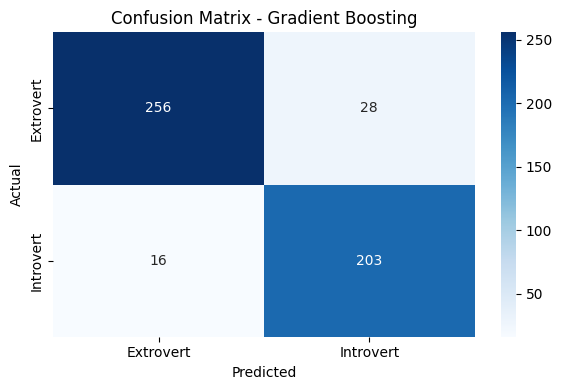

In [29]:
#Gradient Boosting

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train_scaled, y_train_scaled)

y_pred  = gb_model.predict(X_test_scaled)
y_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

# Classification Report
print("Classification Report:")
print(classification_report(y_test_scaled, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_scaled, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Extrovert', 'Introvert'], yticklabels=['Extrovert', 'Introvert'])

plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       284
           1       0.88      0.93      0.90       219

    accuracy                           0.91       503
   macro avg       0.91      0.92      0.91       503
weighted avg       0.92      0.91      0.91       503



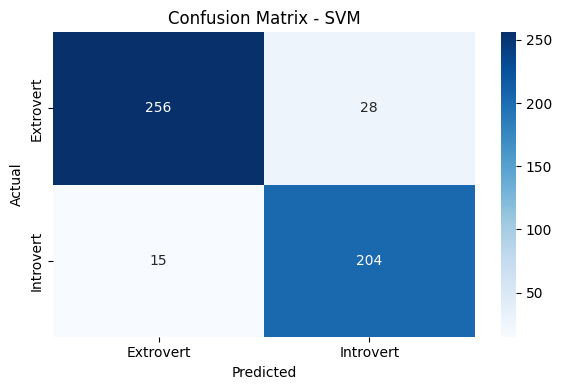

In [30]:
# Final Model — SVM
svm_model = SVC(probability=True, class_weight='balanced')
svm_model.fit(X_train_scaled, y_train_scaled)

y_pred  = svm_model.predict(X_test_scaled)
y_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

# Classification Report
print("Classification Report:")
print(classification_report(y_test_scaled, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_scaled, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Extrovert', 'Introvert'], yticklabels=['Extrovert', 'Introvert'])

plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [28]:
# Save both models
joblib.dump(gb_model,  '../models/gradient_boosting.pkl')
joblib.dump(svm_model, '../models/svm.pkl')

['../models/svm.pkl']